<h1>Import & Setup </h1>

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)

<h1>Data Laoding & Preprocessing </h1>

In [2]:
df = pd.read_csv("../dataset/medical_insurance_encoded.csv")
df.head()
x = df.drop("charges", axis=1)
y = df["charges"]
print(x.head())
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

   cat__sex_male  cat__smoker_yes  cat__region_northwest  \
0            0.0              1.0                    0.0   
1            1.0              0.0                    0.0   
2            1.0              0.0                    0.0   
3            1.0              0.0                    1.0   
4            1.0              0.0                    1.0   

   cat__region_southeast  cat__region_southwest  remainder__age  \
0                    0.0                    1.0            19.0   
1                    1.0                    0.0            18.0   
2                    1.0                    0.0            28.0   
3                    0.0                    0.0            33.0   
4                    0.0                    0.0            32.0   

   remainder__bmi  remainder__children  remainder__smoker_bmi  \
0          27.900                  0.0                   27.9   
1          33.770                  1.0                    0.0   
2          33.000                  3.0   

<h1>SVR Model Training </h1>

In [3]:
svr = SVR(kernel='rbf', C=100000, gamma=0.1, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel='rbf', C=100000, gamma=0.1, epsilon=0.1))
])
cv_scores = cross_val_score(svr_pipeline, x, y, cv=5, scoring='r2')

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)
print("R² per fold:", cv_scores)
print(f"Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

MAE : 1643.1058715178806
MSE : 19852471.579267524
RMSE : 4455.611246424841
R2 : 0.8919629037394529
R² per fold: [0.87421674 0.78379713 0.88228317 0.84034116 0.84206635]
Mean R²: 0.8445 ± 0.0347


<h1> Hyperparameter Tuning </h1>

In [4]:
# param_grid= {
#     'kernel': ['rbf'],
#     'C': [1, 10000, 10000, 100000,100],
#     'gamma': ['scale',0.1, 0.01, 0.001, 0.0001],
#     'epsilon': [0.01, 0.1, 0.5, 1, 1.5]
# }
# grid_search = GridSearchCV(estimator=SVR(), param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2)
# grid_search.fit(X_train_scaled, y_train)

<h1>Final Model Training & Cross Validation </h1>

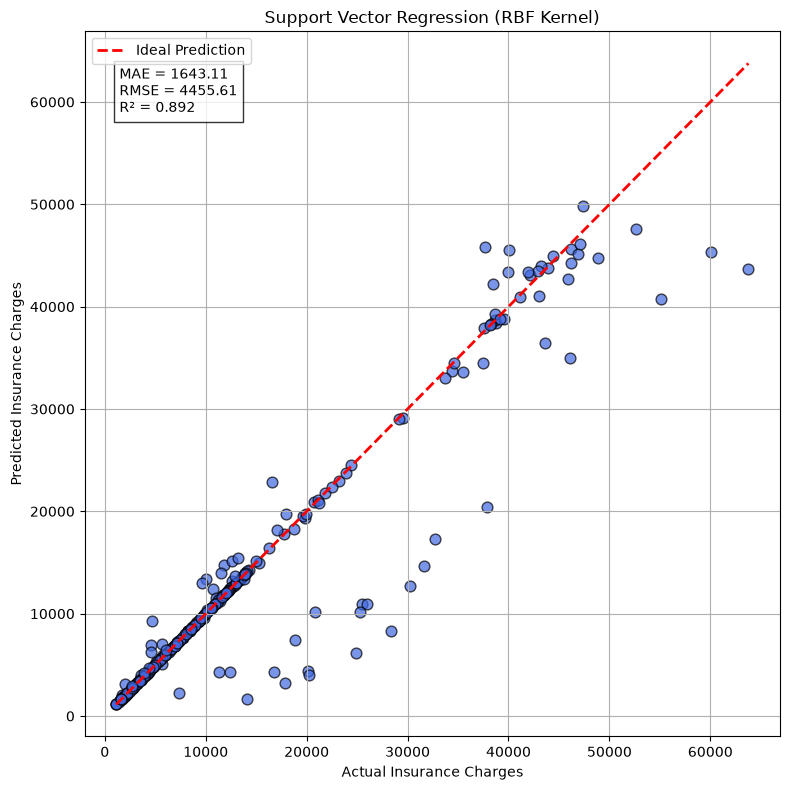

In [5]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    color='royalblue',
    edgecolor='black',
    alpha=0.7,
    s=60
)

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Ideal Prediction'
)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Support Vector Regression (RBF Kernel)")
plt.legend()
plt.grid(True)

# Display metrics
plt.text(
    0.05,
    0.95,
    f"MAE = {mae:.2f}\nRMSE = {rmse:.2f}\nR² = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

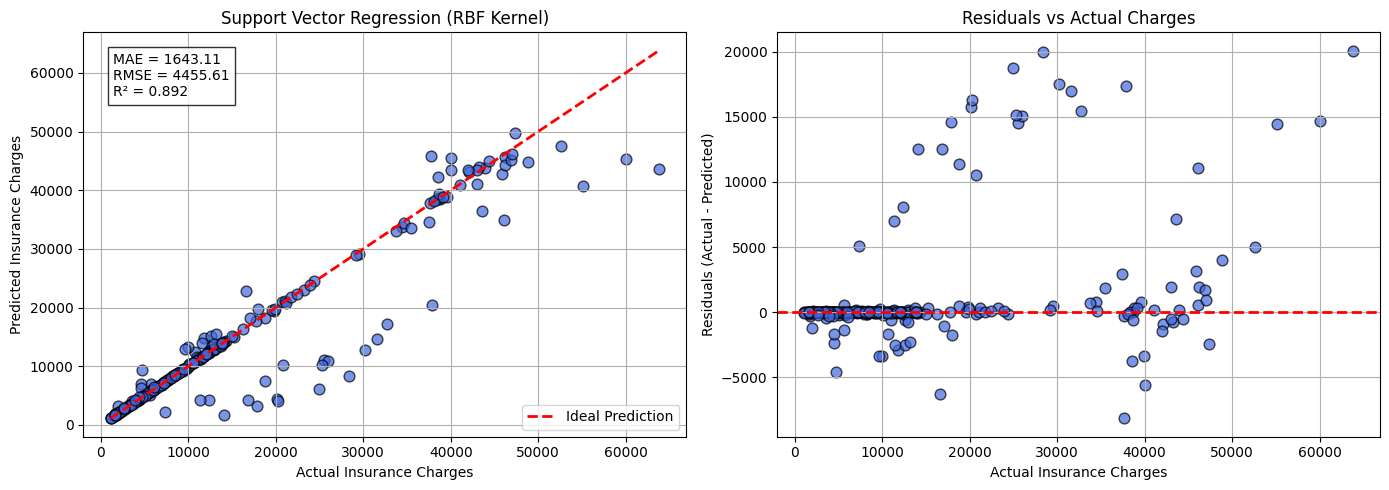

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted (your existing plot)
axes[0].scatter(y_test, y_pred, color='royalblue', edgecolor='black', alpha=0.7, s=60)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
axes[0].set_xlabel("Actual Insurance Charges")
axes[0].set_ylabel("Predicted Insurance Charges")
axes[0].set_title("Support Vector Regression (RBF Kernel)")
axes[0].legend()
axes[0].grid(True)
axes[0].text(
    0.05, 0.95, f"MAE = {mae:.2f}\nRMSE = {rmse:.2f}\nR² = {r2:.3f}",
    transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

# Plot 2: Residuals Plot
residuals = y_test - y_pred
axes[1].scatter(y_test, residuals, color='royalblue', edgecolor='black', alpha=0.7, s=60)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Actual Insurance Charges")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("Residuals vs Actual Charges")
axes[1].grid(True)

plt.tight_layout()
plt.show()

<h1>Feature Importance Analysis</h1>

In [6]:
perm_importance = permutation_importance(
    svr, X_test_scaled, y_test,
    n_repeats=30, random_state=42, scoring='r2'
)

importances = pd.Series(
    perm_importance.importances_mean, index=X_train.columns
).sort_values(ascending=False)

print("Feature Importances (Permutation, SVR RBF):")
print(importances)

Feature Importances (Permutation, SVR RBF):
remainder__obese_smoker       0.224521
remainder__smoker_bmi         0.194931
remainder__age_smoker         0.144651
cat__smoker_yes               0.127580
remainder__age                0.064762
remainder__age_squared        0.045730
remainder__children_smoker    0.040338
remainder__bmi                0.031177
remainder__is_obese           0.024809
remainder__children           0.024066
remainder__is_underweight     0.016974
cat__region_southwest         0.006889
cat__region_southeast         0.006299
cat__region_northwest         0.004195
cat__sex_male                -0.000821
dtype: float64


In [8]:
n_sv = svr.support_.shape[0]
n_train = X_train_scaled.shape[0]
print(f"Support vectors: {n_sv} / {n_train} ({n_sv/n_train:.1%})")

Support vectors: 1062 / 1069 (99.3%)


<h1>Export Model</h1>

In [7]:
joblib.dump(scaler, "../models/svr_scaler.pkl")
joblib.dump(svr, "../models/svr_rbf_model.pkl")

['../models/svr_rbf_model.pkl']